# Lagrangian Mechanics Applied to Circuits

**Noether's theorem**: time translation symmetry -> energy H=T+V conserved.

Circuit Lagrangian analogy:
- Charge q = generalized position
- Current I = dq/dt = generalized velocity
- Inductance L = mass (kinetic energy = (1/2)LI^2)
- 1/C = spring constant (potential energy = q^2/(2C))
- Resistance R = damping (Rayleigh dissipation)
- Euler-Lagrange equation = Kirchhoff's Voltage Law


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from dgs.lagrangian_circuits import (
    lagrangian_rlc_sympy, noether_energy_sympy, euler_lagrange_solve,
    power_iv, thevenin_norton, open_circuit_limit, power_sweep_R,
    circuit_analogy_table, action_integral,
    normal_modes_coupled, lagrangian_transmission_line, lagrangian_sympy_5,
)
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
print("Loaded.")


Loaded.


## S2 Five Key Equations with sp.init_printing

In [2]:
sp.init_printing(use_latex=False)
eqs = lagrangian_sympy_5()
print("=" * 60)
print("LAGRANGIAN / CIRCUIT EQUATIONS")
print("=" * 60)
for name, eq in eqs.items():
    print(f"\n  [{name}]\n    {eq}")


LAGRANGIAN / CIRCUIT EQUATIONS

  [Lagrangian L=T-V]
    Eq(L_c, L*dq**2/2 - q**2/(2*C))

  [Hamiltonian H=T+V]
    Eq(H, L*dq**2/2 + q**2/(2*C))

  [canonical_momentum]
    Eq(p, L*dq)

  [Euler-Lagrange (KVL)]
    Eq(L*ddq + R*dq + q/C, V_s)

  [omega_0]
    Eq(omega_0, 1/(sqrt(C)*sqrt(L)))


## S3 Euler-Lagrange -> KVL (symbolic)

Starting from L = (1/2)L*I^2 - q^2/(2C) and Rayleigh D = (1/2)R*I^2:

d/dt(dL/dI) - dL/dq + dD/dI = V_s

Expands to: L*q'' + R*q' + q/C = V_s  -- this IS KVL.


In [3]:
rlc = lagrangian_rlc_sympy()
print(f"T = {rlc['T']}")
print(f"V = {rlc['V']}")
print(f"D = {rlc['D_rayleigh']}")
print(f"EOM = {rlc['EOM']}")
print(f"Matches KVL: {rlc['EOM_matches_KVL']}")
n = noether_energy_sympy()
print()
print(f"p (flux linkage) = {n['canonical_momentum_p']}")
print(f"H = {n['Hamiltonian_H']}")
print(f"H = T+V verified: {n['H_equals_TplusV']}")


T = L*Derivative(q(t), t)**2/2
V = q(t)**2/(2*C)
D = R*Derivative(q(t), t)**2/2
EOM = Eq(L*Derivative(q(t), (t, 2)) + R*Derivative(q(t), t) + q(t)/C, V_s(t))
Matches KVL: True

p (flux linkage) = Eq(p, L*dq)
H = Eq(H, (C*L*dq**2 + q**2)/(2*C))
H = T+V verified: True


## S4 Mechanical <-> Electrical Analogy

In [4]:
print(circuit_analogy_table())

Mechanical                          Electrical                         
position x                          charge q                           
velocity v = x_dot                  current I = q_dot                  
mass m                              inductance L                       
spring constant k                   1/C (elastance)                    
damping coeff b                     resistance R                       
force F(t)                          voltage V_s(t)                     
kinetic energy (1/2)mv^2            magnetic energy (1/2)LI^2          
potential energy (1/2)kx^2          electric energy (1/2)q^2/C = (1/2)CV^2
momentum p = mv                     flux linkage lambda = LI           
Lagrangian L=T-V                    L_circuit = (1/2)LI^2 - q^2/(2C)   
Hamiltonian H=T+V                   H_EM = (1/2)LI^2 + q^2/(2C) = total EM energy
Noether: time symm                  dH/dt = 0 when no explicit t in L  
natural frequency omega             omega_0 = 1/sqr

## S5 Numerical RLC Step Response

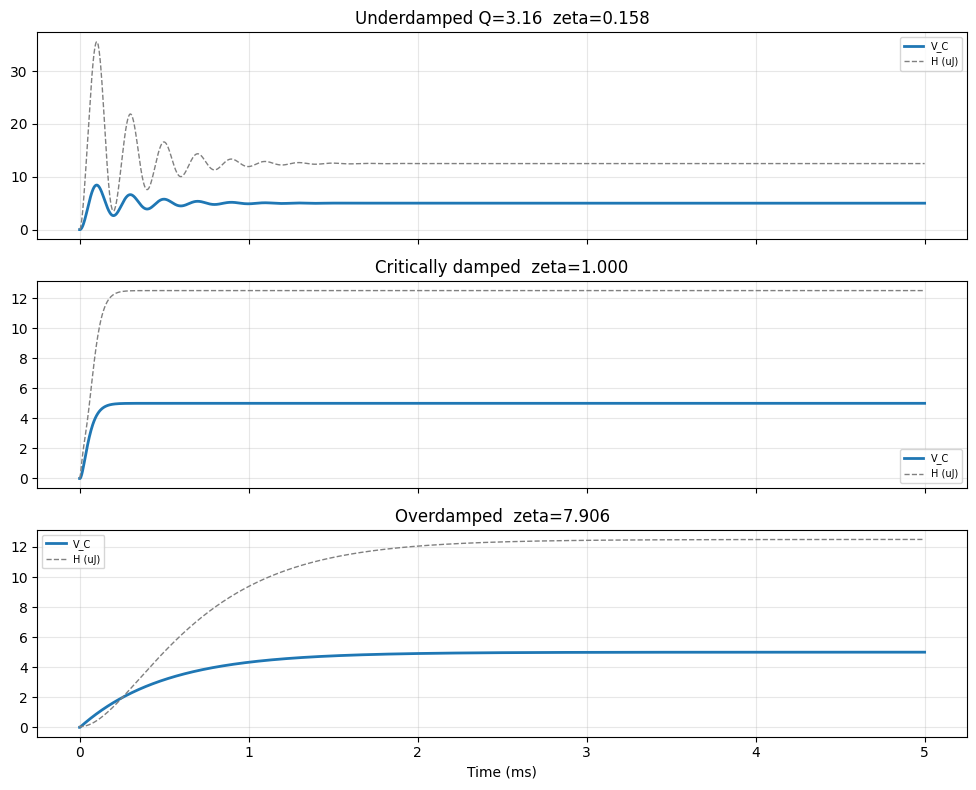

In [5]:
L_H, C_F = 1e-3, 1e-6
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
configs = [(10.0, "Underdamped Q=3.16"), (63.25, "Critically damped"), (500.0, "Overdamped")]
for ax, (R, label) in zip(axes, configs):
    res = euler_lagrange_solve(L_H, R, C_F, lambda t: 5.0, (0, 5e-3))
    ax.plot(res["t"]*1e3, res["V_C"], lw=2, label="V_C")
    ax.plot(res["t"]*1e3, res["H"]*1e6, lw=1, ls="--", color="gray", label="H (uJ)")
    ax.set_title(f"{label}  zeta={R/(2*np.sqrt(L_H/C_F)):.3f}")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.savefig("rlc_damping.png", dpi=90)
plt.show()


## S6 Action Integral: Principle of Least Action

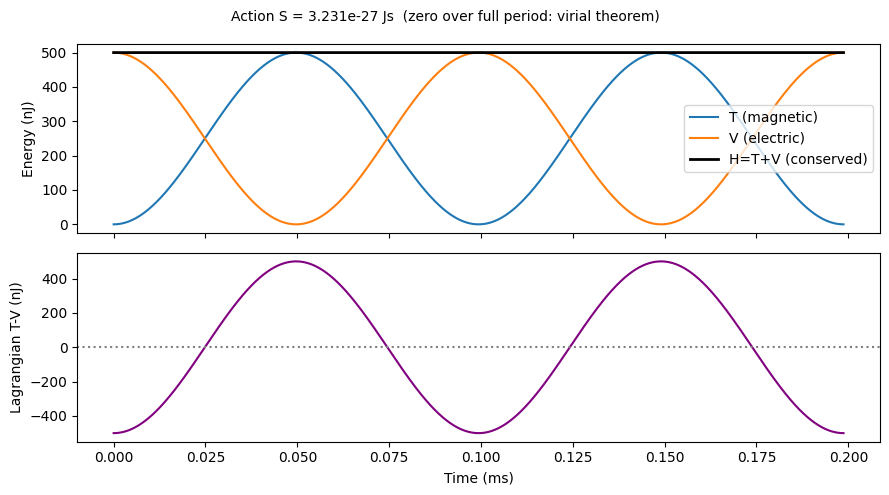

omega_0 = 31622.8 rad/s = 5032.9 Hz
Action S = 3.2312e-27 J*s  (should be ~0 over full period)


In [6]:
L_H, C_F = 1e-3, 1e-6
omega_0 = 1 / np.sqrt(L_H * C_F)
t = np.linspace(0, 2 * np.pi / omega_0, 5000)
A = 1e-6
q = A * np.cos(omega_0 * t)
I = -A * omega_0 * np.sin(omega_0 * t)
T_arr = 0.5 * L_H * I**2
V_arr = 0.5 * q**2 / C_F
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(t*1e3, T_arr*1e9, label="T (magnetic)")
axes[0].plot(t*1e3, V_arr*1e9, label="V (electric)")
axes[0].plot(t*1e3, (T_arr + V_arr)*1e9, "k", lw=2, label="H=T+V (conserved)")
axes[0].legend(); axes[0].set_ylabel("Energy (nJ)")
axes[1].plot(t*1e3, (T_arr - V_arr)*1e9, color="purple")
axes[1].axhline(0, color="gray", ls=":")
axes[1].set_ylabel("Lagrangian T-V (nJ)"); axes[1].set_xlabel("Time (ms)")
S = action_integral(t, q, I, L_H, C_F)
plt.suptitle(f"Action S = {S:.3e} Js  (zero over full period: virial theorem)", fontsize=10)
plt.tight_layout()
plt.savefig("action_lc.png", dpi=90)
plt.show()
print(f"omega_0 = {omega_0:.1f} rad/s = {omega_0/(2*np.pi):.1f} Hz")
print(f"Action S = {S:.4e} J*s  (should be ~0 over full period)")


## S7 Normal Modes: Two Coupled LC Oscillators

omega_0           = 31622.8 rad/s
omega_symmetric   = 31622.8 rad/s  (in-phase)
omega_antisymm    = 34641.0 rad/s  (out-of-phase)
Freq splitting    = 3018.2 rad/s


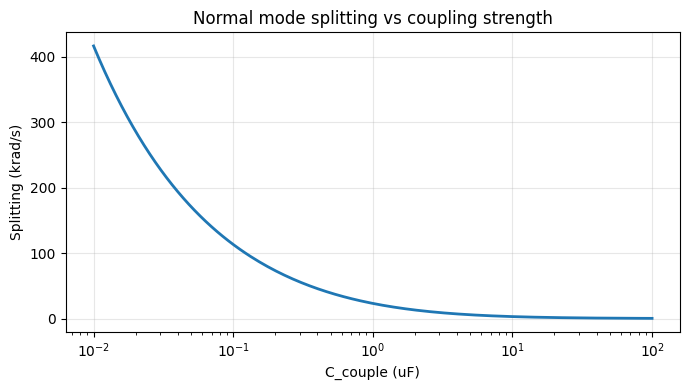

In [7]:
nm = normal_modes_coupled(1e-3, 1e-6, 10e-6)
print(f"omega_0           = {nm['omega_0']:.1f} rad/s")
print(f"omega_symmetric   = {nm['omega_symmetric']:.1f} rad/s  (in-phase)")
print(f"omega_antisymm    = {nm['omega_antisymmetric']:.1f} rad/s  (out-of-phase)")
print(f"Freq splitting    = {nm['freq_splitting']:.1f} rad/s")
C_arr = np.logspace(-8, -4, 200)
split = [normal_modes_coupled(1e-3, 1e-6, Cc)["freq_splitting"] for Cc in C_arr]
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(C_arr*1e6, np.array(split)/1e3, lw=2)
ax.set_xlabel("C_couple (uF)"); ax.set_ylabel("Splitting (krad/s)")
ax.set_title("Normal mode splitting vs coupling strength")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("normal_modes.png", dpi=90)
plt.show()


## S8 Transmission Line: LC Ladder -> Wave Equation

Z0 = 50.0 Ohm
v_p = 2.000e+08 m/s  (66.7% of c)
Wave eq: d^2V/dt^2 = (1/LC) * d^2V/dx^2


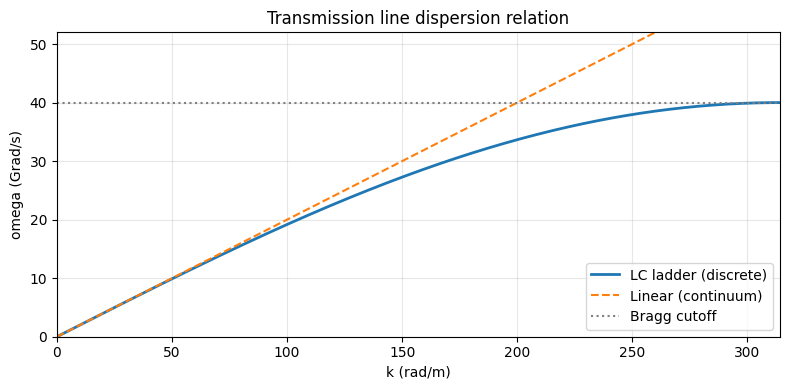

In [8]:
tl = lagrangian_transmission_line()
print(f"Z0 = {tl['Z0']:.1f} Ohm")
print(f"v_p = {tl['v_phase']:.3e} m/s  ({tl['v_phase']/3e8*100:.1f}% of c)")
print(f"Wave eq: {tl['wave_eq']}")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tl["k_arr"], tl["omega_arr"]/1e9, lw=2, label="LC ladder (discrete)")
ax.plot(tl["k_arr"], tl["v_phase"]*tl["k_arr"]/1e9, ls="--", label="Linear (continuum)")
ax.axhline(tl["omega_cutoff"]/1e9, color="gray", ls=":", label="Bragg cutoff")
ax.set_xlabel("k (rad/m)"); ax.set_ylabel("omega (Grad/s)")
ax.set_title("Transmission line dispersion relation")
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlim(0, tl["k_arr"].max()); ax.set_ylim(0, tl["omega_cutoff"]/1e9 * 1.3)
plt.tight_layout()
plt.savefig("tline_disp.png", dpi=90)
plt.show()


## S9 Power P=IV; Maximum Power Transfer; R -> infinity

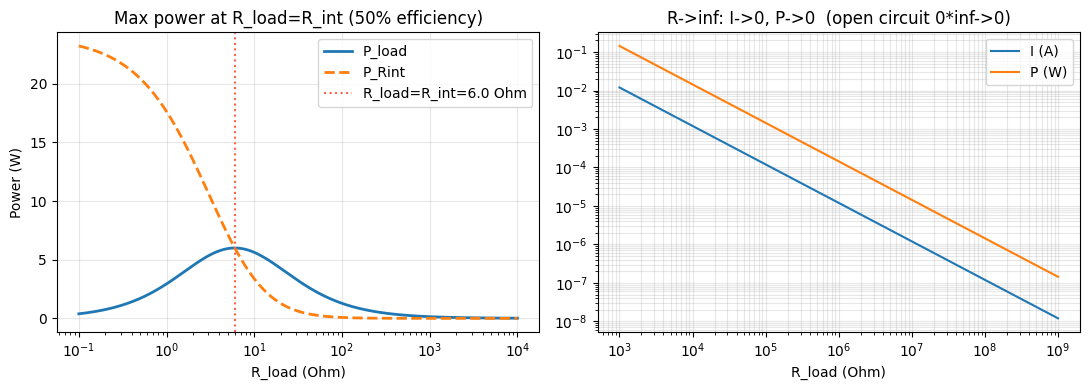

P_max = 6.00 W at R_load=R_th=6.0 Ohm


In [9]:
R_int = 6.0; V_oc = 12.0
R_arr = np.logspace(-1, 4, 500)
sw = power_sweep_R(V_oc, R_int, R_arr)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogx(R_arr, sw["P_load"], lw=2, label="P_load")
axes[0].semilogx(R_arr, sw["P_dissipated_Rint"], lw=2, ls="--", label="P_Rint")
axes[0].axvline(R_int, color="tomato", ls=":", label=f"R_load=R_int={R_int} Ohm")
axes[0].set_xlabel("R_load (Ohm)"); axes[0].set_ylabel("Power (W)")
axes[0].set_title("Max power at R_load=R_int (50% efficiency)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
R_large = np.logspace(3, 9, 200)
I_arr = np.array([open_circuit_limit(V_oc, R)["I"] for R in R_large])
P_arr = np.array([open_circuit_limit(V_oc, R)["P_load"] for R in R_large])
axes[1].loglog(R_large, I_arr, label="I (A)")
axes[1].loglog(R_large, P_arr, label="P (W)")
axes[1].set_xlabel("R_load (Ohm)")
axes[1].set_title("R->inf: I->0, P->0  (open circuit 0*inf->0)")
axes[1].legend(); axes[1].grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("power_iv.png", dpi=90)
plt.show()
th = thevenin_norton(V_oc, V_oc / R_int)
print(f"P_max = {th['max_power_transfer']:.2f} W at R_load=R_th={th['R_load_for_max_power']:.1f} Ohm")


## S10 GS Phase Retrieval as Variational Principle

The Gerchberg-Saxton loss L_GS plays the same role as the Lagrangian:

| GS phase retrieval | Circuit Lagrangian |
|---|---|
| Loss L_GS | Lagrangian L = T-V |
| I1, I2 constraints | Boundary conditions q(0), q(T) |
| GS iterations | Euler-Lagrange time steps |
| L_GS -> 0 | EOM satisfied |
| Phase rotation symmetry | Time translation symmetry |
| int|E|^2 conserved | H = T+V conserved (Noether) |


In [10]:
print("GS <-> Lagrangian analogy (Noether connection):")
rows = [
    ("GS loss L_GS",         "Lagrangian L = T-V"),
    ("I1, I2 constraints",   "BC q(0), q(T)"),
    ("GS iterations",        "E-L time steps dt"),
    ("L_GS -> 0",            "EOM satisfied"),
    ("Phase rotation sym",   "Time translation sym"),
    ("int|E|^2 conserved",   "H = T+V conserved"),
]
for gs, lag in rows:
    print(f"  {gs:<28} <->  {lag}")


GS <-> Lagrangian analogy (Noether connection):
  GS loss L_GS                 <->  Lagrangian L = T-V
  I1, I2 constraints           <->  BC q(0), q(T)
  GS iterations                <->  E-L time steps dt
  L_GS -> 0                    <->  EOM satisfied
  Phase rotation sym           <->  Time translation sym
  int|E|^2 conserved           <->  H = T+V conserved
